# ICU 72h Mortality Prediction — Improved Pipeline
**Changes from previous version:**
- **Clinical recall scorer** — optimise recall with precision floor (≥ 0.40)
- **SMOTE only** (removed SMOTEENN — ENN cleaning was removing real minority samples)
- **Platt calibration** instead of isotonic (more stable with small cal sets)
- **XGBoost explicitly in ensemble** with `scale_pos_weight`
- **Threshold sweep table** printed for full transparency

In [1]:
# Install dependencies
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', 'xgboost', '-q'])
print('Installation complete.')

Installation complete.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [3]:
icu_final_df = pd.read_csv('mimic dataset/icu_final_df.csv')

X = icu_final_df.drop('mortality_icu', axis=1)
y = icu_final_df['mortality_icu']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'Dataset shape : {X.shape}')
print(f'Class balance :\n{y.value_counts()}')
print(f'Minority ratio: {y.mean():.2%}')

Dataset shape : (47291, 55)
Class balance :
mortality_icu
0    41564
1     5727
Name: count, dtype: int64
Minority ratio: 12.11%


## 2. Preprocessing

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# StandardScaler: required for SMOTE distance computation to be meaningful
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
])

print('Preprocessor defined.')

Preprocessor defined.


## 3. Train / Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (37832, 55)  |  Test: (9459, 55)


## 4. Clinical Recall Scorer

**Why not pure recall?**  
Optimising recall alone makes the model predict *death* for everyone → recall=1.0, precision≈0.12 (useless).  
The custom scorer returns recall only when `precision >= PRECISION_FLOOR`, otherwise returns 0.  
This forces CV to find configs that *catch deaths* without becoming a rubber stamp.

**Tune `PRECISION_FLOOR`:**
- `0.30` → very aggressive (max recall, many false alarms)  
- `0.40` → balanced starting point  
- `0.50` → conservative (only flag when confident)

In [6]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, precision_score
from scipy.stats import randint, uniform

PRECISION_FLOOR = 0.40   # tune to your clinical tolerance

def recall_with_precision_floor(y_true, y_pred, precision_floor=PRECISION_FLOOR):
    precision = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    # Disqualify configs whose precision is unacceptably low
    if precision < precision_floor:
        return 0.0
    return recall

clinical_scorer = make_scorer(recall_with_precision_floor)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'CV scorer: Recall (minority) with Precision floor >= {PRECISION_FLOOR}')

CV scorer: Recall (minority) with Precision floor >= 0.4


## 5. SMOTE  (imblearn Pipeline)

**Why SMOTE instead of SMOTEENN?**  
SMOTEENN's ENN cleaning step aggressively removes real minority samples it considers borderline-noisy.  
On medical data this worsens class imbalance rather than fixing it. Plain SMOTE only adds synthetic samples — safer.

In [7]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print('imblearn imported. SMOTE will be applied only on training folds.')

imblearn imported. SMOTE will be applied only on training folds.


## 6a. HistGradientBoosting

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier

pipe_hgb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('model',        HistGradientBoostingClassifier(
                         class_weight='balanced',
                         random_state=42
                     ))
])

hgb_param_dist = {
    'model__max_depth':         randint(3, 10),
    'model__learning_rate':     uniform(0.01, 0.15),
    'model__max_iter':          randint(150, 500),
    'model__min_samples_leaf':  randint(10, 50),
    'model__l2_regularization': uniform(0.0, 1.0),
}

hgb_search = RandomizedSearchCV(
    pipe_hgb,
    param_distributions=hgb_param_dist,
    n_iter=30,
    scoring=clinical_scorer,
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
hgb_search.fit(X_train, y_train)
best_hgb = hgb_search.best_estimator_

print('\nBest HGB params:', hgb_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best HGB params: {'model__l2_regularization': np.float64(0.8021969807540397), 'model__learning_rate': np.float64(0.021182596551965624), 'model__max_depth': 9, 'model__max_iter': 158, 'model__min_samples_leaf': 33}


## 6b. Random Forest  —  `class_weight` as hyperparameter

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Search over explicit weight ratios instead of just 'balanced'
class_weight_options = [{0: 1, 1: w} for w in [5, 7, 10, 15, 20]]

pipe_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('model',        RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'model__n_estimators':      randint(200, 600),
    'model__max_depth':         [None, 10, 20, 30],
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf':  randint(1, 5),
    'model__max_features':      ['sqrt', 'log2'],
    'model__class_weight':      class_weight_options,
}

rf_search = RandomizedSearchCV(
    pipe_rf,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring=clinical_scorer,
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print('\nBest RF params:', rf_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best RF params: {'model__class_weight': {0: 1, 1: 5}, 'model__max_depth': 30, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 8, 'model__n_estimators': 338}


## 6c. XGBoost  —  `scale_pos_weight` for native imbalance handling

In [10]:
from xgboost import XGBClassifier

# scale_pos_weight = count(negative) / count(positive)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {pos_weight:.2f}')

pipe_xgb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42, k_neighbors=5)),
    ('model',        XGBClassifier(
                         scale_pos_weight=pos_weight,
                         eval_metric='aucpr',
                         random_state=42,
                         n_jobs=-1,
                         verbosity=0
                     ))
])

xgb_param_dist = {
    'model__n_estimators':      randint(200, 600),
    'model__max_depth':         randint(3, 10),
    'model__learning_rate':     uniform(0.01, 0.15),
    'model__subsample':         uniform(0.6, 0.4),
    'model__colsample_bytree':  uniform(0.6, 0.4),
    'model__reg_lambda':        uniform(0.5, 2.0),
}

xgb_search = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring=clinical_scorer,
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print('\nBest XGB params:', xgb_search.best_params_)

scale_pos_weight = 7.26
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB params: {'model__colsample_bytree': np.float64(0.8136357677501768), 'model__learning_rate': np.float64(0.08272449570384748), 'model__max_depth': 3, 'model__n_estimators': 506, 'model__reg_lambda': np.float64(1.038824667597043), 'model__subsample': np.float64(0.6976502088991097)}


## 7. Soft-Voting Ensemble  (HGB + RF + XGB)

Weights: HGB=2, RF=1, XGB=2  
HGB and XGB weighted higher as gradient boosters generally outperform RF on tabular medical data.

In [11]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('hgb', best_hgb),
        ('rf',  best_rf),
        ('xgb', best_xgb),
    ],
    voting='soft',
    weights=[2, 1, 2]
)

ensemble.fit(X_train, y_train)
print('Ensemble fitted: HGB (w=2) + RF (w=1) + XGB (w=2)')

Ensemble fitted: HGB (w=2) + RF (w=1) + XGB (w=2)


## 8. Probability Calibration  (Platt / sigmoid)

**Why sigmoid instead of isotonic?**  
Isotonic calibration needs many samples to fit reliably — with a small imbalanced cal set it can warp probabilities badly.  
Sigmoid (Platt scaling) fits only 2 parameters and is far more stable in this setting.

In [12]:
from sklearn.calibration import CalibratedClassifierCV

# Hold out 15% of training data for calibration
X_tr2, X_cal, y_tr2, y_cal = train_test_split(
    X_train, y_train, test_size=0.15, random_state=99, stratify=y_train
)

In [13]:
ensemble.fit(X_tr2, y_tr2)

# sigmoid = Platt scaling — 2-parameter fit, stable with small/imbalanced cal sets
calibrated = CalibratedClassifierCV(ensemble, method='sigmoid', cv='prefit')
calibrated.fit(X_cal, y_cal)

print('Calibration done (Platt sigmoid on held-out 15%).')

Calibration done (Platt sigmoid on held-out 15%).


## 9. Threshold Sweep  +  Clinical Selection

Prints a full table across thresholds 0.20 → 0.55, then selects the best threshold  
where `Recall >= RECALL_FLOOR` and `Precision >= PRECISION_FLOOR`.

In [16]:
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

y_prob = calibrated.predict_proba(X_test)[:, 1]

# Full threshold sweep table
print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>8} | {"F1":>8}')
print('-' * 46)
for t in np.arange(0.20, 0.56, 0.05):
    y_pred_t = (y_prob >= t).astype(int)
    p = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    r = recall_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    f = f1_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    print(f'{t:>10.2f} | {p:>10.3f} | {r:>8.3f} | {f:>8.3f}')

# Clinical selection: Recall >= floor, then maximise F1
RECALL_FLOOR    = 0.80
PRECISION_FLOOR = 0.40

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_prob)

best_threshold = None
best_f1 = 0.0

for p, r, t in zip(precision_arr, recall_arr, thresholds_arr):
    if r >= RECALL_FLOOR and p >= PRECISION_FLOOR:
        f1 = 2 * p * r / (p + r + 1e-9)
        if f1 > best_f1:
            best_f1        = f1
            best_threshold = t
            best_p, best_r = p, r

if best_threshold is None:
    print('\nNo threshold met both constraints — falling back to pure F1 optimum.')
    f1_scores = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-9)
    idx = np.argmax(f1_scores)
    best_threshold = thresholds_arr[idx]
    best_p, best_r, best_f1 = precision_arr[idx], recall_arr[idx], f1_scores[idx]

print(f'\n-> Selected Threshold : {best_threshold:.4f}')
print(f'-> Precision          : {best_p:.3f}')
print(f'-> Recall             : {best_r:.3f}')
print(f'-> F1                 : {best_f1:.3f}')

 Threshold |  Precision |   Recall |       F1
----------------------------------------------
      0.20 |      0.501 |    0.739 |    0.597
      0.25 |      0.542 |    0.690 |    0.607
      0.30 |      0.571 |    0.645 |    0.606
      0.35 |      0.613 |    0.615 |    0.614
      0.40 |      0.652 |    0.569 |    0.608
      0.45 |      0.681 |    0.522 |    0.591
      0.50 |      0.715 |    0.477 |    0.572
      0.55 |      0.743 |    0.419 |    0.536

-> Selected Threshold : 0.1428
-> Precision          : 0.448
-> Recall             : 0.802
-> F1                 : 0.575


## 10. Final Evaluation

In [17]:
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

y_pred = (y_prob >= best_threshold).astype(int)

print('=' * 55)
print('CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred,
      target_names=['Survived (0)', 'Died (1)']))

print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob):.4f}')

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.97      0.86      0.91      8314
    Died (1)       0.45      0.80      0.58      1145

    accuracy                           0.86      9459
   macro avg       0.71      0.83      0.74      9459
weighted avg       0.91      0.86      0.87      9459

ROC-AUC : 0.9155
PR-AUC  : 0.6729


## 11. Plots

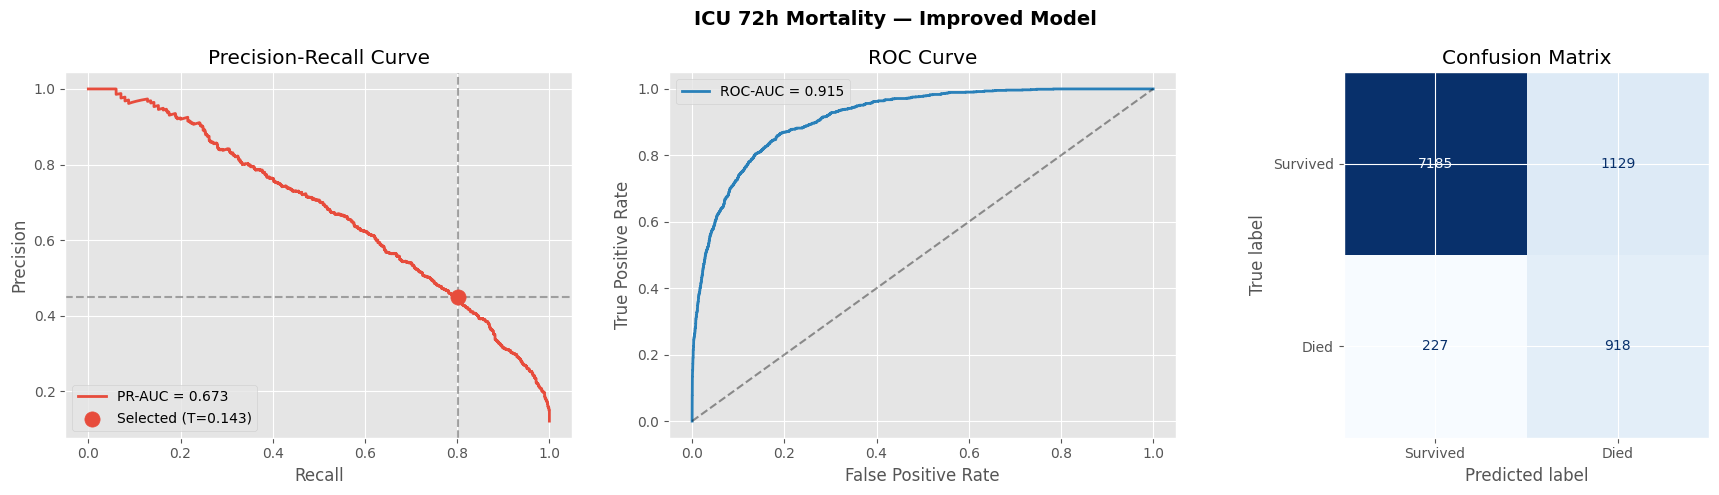

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision-Recall Curve
pr_auc = average_precision_score(y_test, y_prob)
axes[0].plot(recall_arr, precision_arr, lw=2, color='#e74c3c',
             label=f'PR-AUC = {pr_auc:.3f}')
axes[0].axvline(best_r, color='gray', linestyle='--', alpha=0.7)
axes[0].axhline(best_p, color='gray', linestyle='--', alpha=0.7)
axes[0].scatter([best_r], [best_p], s=120, zorder=5, color='#e74c3c',
                label=f'Selected (T={best_threshold:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, color='#2980b9',
             label=f'ROC-AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Survived', 'Died'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix')

plt.suptitle('ICU 72h Mortality — Improved Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Feature Importance  (HGB)

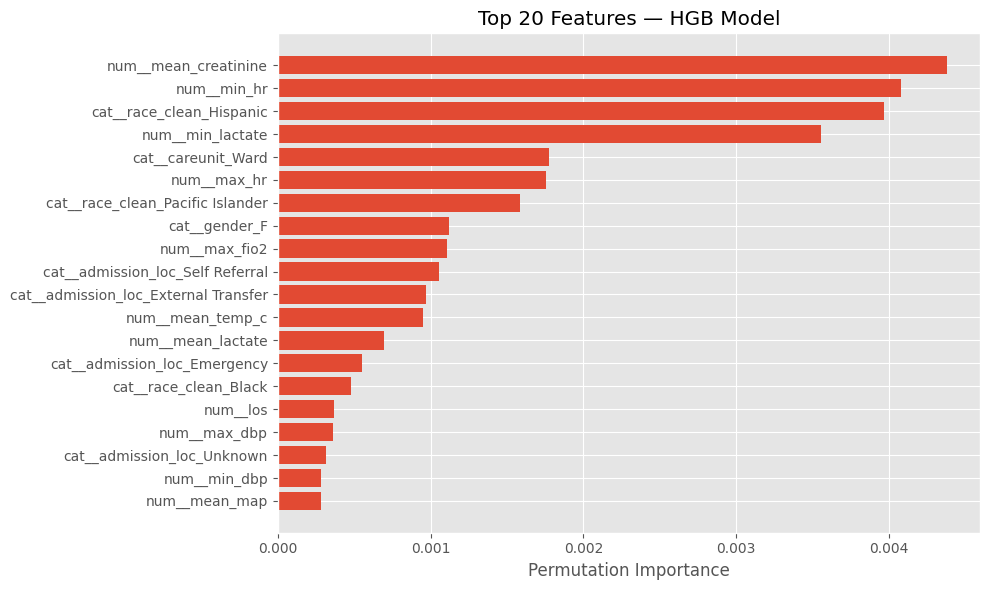

In [19]:
from sklearn.inspection import permutation_importance

feature_names = best_hgb.named_steps['preprocessor'].get_feature_names_out()

result = permutation_importance(
    best_hgb,          # use full pipeline (simpler)
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

importances = result.importances_mean

top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    feature_names[top_idx][::-1],
    importances[top_idx][::-1]
)
ax.set_title(f'Top {top_n} Features — HGB Model')
ax.set_xlabel('Permutation Importance')

plt.tight_layout()
plt.show()

## 13. Save Model & Threshold

In [17]:
import joblib

joblib.dump(calibrated,     'icu_mortality_model.pkl')
joblib.dump(best_threshold, 'icu_mortality_threshold.pkl')

print('Model saved     -> icu_mortality_model.pkl')
print('Threshold saved -> icu_mortality_threshold.pkl')

Model saved     -> icu_mortality_model.pkl
Threshold saved -> icu_mortality_threshold.pkl


## 14. Inference Helper

In [18]:
import joblib

def predict_mortality(
    X_new: pd.DataFrame,
    model_path='icu_mortality_model.pkl',
    threshold_path='icu_mortality_threshold.pkl'
) -> pd.DataFrame:
    
    model     = joblib.load(model_path)
    threshold = joblib.load(threshold_path)

    probs = model.predict_proba(X_new)[:, 1]
    preds = (probs >= threshold).astype(int)
    risk  = pd.cut(probs,
                   bins=[0, 0.3, 0.6, 1.0],
                   labels=['Low', 'Medium', 'High'])

    return pd.DataFrame({
        'death_probability': probs.round(4),
        'prediction':        preds,
        'risk_level':        risk
    }, index=X_new.index)


# Example usage:
# results = predict_mortality(X_test.head(10))
# results

## 15. Lightweight HGB Model for Deployment

In [20]:
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

hgb_pipeline = best_hgb  

# Calibrate HGB independently using same calibration split 
from sklearn.calibration import CalibratedClassifierCV

hgb_calibrated = CalibratedClassifierCV(hgb_pipeline, method='sigmoid', cv='prefit')
hgb_calibrated.fit(X_cal, y_cal)

# Evaluate HGB alone 
y_prob_hgb = hgb_calibrated.predict_proba(X_test)[:, 1]

print('=' * 55)
print('HGB STANDALONE PERFORMANCE')
print('=' * 55)
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_hgb):.3f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob_hgb):.3f}')
print()

# ── Threshold sweep for HGB ──
print(f'{"Threshold":>10} | {"Precision":>10} | {"Recall":>8} | {"F1":>8}')
print('-' * 46)
thresholds_hgb = np.arange(0.05, 0.60, 0.01)
best_hgb_threshold = None
best_hgb_f1 = 0

for t in thresholds_hgb:
    yp = (y_prob_hgb >= t).astype(int)
    p  = precision_score(y_test, yp, zero_division=0)
    r  = recall_score(y_test, yp, zero_division=0)
    f1 = f1_score(y_test, yp, zero_division=0)
    marker = ' ← candidate' if r >= 0.80 and p >= 0.39 else ''
    print(f'{t:>10.3f} | {p:>10.3f} | {r:>8.3f} | {f1:>8.3f}{marker}')
    if r >= 0.80 and p >= 0.39 and f1 > best_hgb_f1:
        best_hgb_f1 = f1
        best_hgb_threshold = t

print()
if best_hgb_threshold:
    print(f'Best HGB threshold : {best_hgb_threshold:.4f}')
    yp = (y_prob_hgb >= best_hgb_threshold).astype(int)
    print(classification_report(y_test, yp, target_names=['Survived','Died']))
else:
    print('No threshold meets recall>=0.80 and precision>=0.40')
    best_hgb_threshold = 0.143

HGB STANDALONE PERFORMANCE
ROC-AUC : 0.899
PR-AUC  : 0.635

 Threshold |  Precision |   Recall |       F1
----------------------------------------------
     0.050 |      0.294 |    0.898 |    0.443
     0.060 |      0.311 |    0.878 |    0.459
     0.070 |      0.327 |    0.859 |    0.474
     0.080 |      0.343 |    0.850 |    0.489
     0.090 |      0.359 |    0.838 |    0.502
     0.100 |      0.369 |    0.819 |    0.509
     0.110 |      0.383 |    0.810 |    0.520
     0.120 |      0.399 |    0.802 |    0.533 ← candidate
     0.130 |      0.412 |    0.789 |    0.541
     0.140 |      0.424 |    0.776 |    0.548
     0.150 |      0.438 |    0.764 |    0.557
     0.160 |      0.447 |    0.748 |    0.560
     0.170 |      0.459 |    0.731 |    0.564
     0.180 |      0.471 |    0.714 |    0.568
     0.190 |      0.478 |    0.705 |    0.569
     0.200 |      0.488 |    0.690 |    0.571
     0.210 |      0.500 |    0.680 |    0.577
     0.220 |      0.510 |    0.665 |    0.577
     0.

## 16. Save Lightweight HGB Model

In [21]:
import os
import joblib

# Save
joblib.dump(hgb_calibrated,    'icu_mortality_model_light.pkl')
joblib.dump(best_hgb_threshold, 'icu_mortality_threshold_light.pkl')

# Check sizes
ensemble_size = os.path.getsize('icu_mortality_model.pkl') / 1024 / 1024
light_size    = os.path.getsize('icu_mortality_model_light.pkl') / 1024 / 1024

print(f'Ensemble model size : {ensemble_size:.1f} MB')
print(f'HGB light model size: {light_size:.1f} MB')
print(f'Size reduction      : {((ensemble_size-light_size)/ensemble_size)*100:.0f}%')
print()
print(f'Ensemble threshold  : {best_threshold:.4f}')
print(f'HGB threshold       : {best_hgb_threshold:.4f}')
print()
print('Saved:')
print('  icu_mortality_model_light.pkl')
print('  icu_mortality_threshold_light.pkl')

Ensemble model size : 360.7 MB
HGB light model size: 5.2 MB
Size reduction      : 99%

Ensemble threshold  : 0.1428
HGB threshold       : 0.1200

Saved:
  icu_mortality_model_light.pkl
  icu_mortality_threshold_light.pkl
